In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "src").exists():
    project_root = cwd
elif (cwd.parent / "src").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError("Could not locate project root containing 'src'.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
import statsmodels.api as sm


In [ ]:

from src.data.create_dataframes import processed_df_map

pd.set_option("display.float_format", "{:,.4f}".format)

DEFAULT_Y_COL_MAP = {
    "eur_df_processed": "EURUSD",
    "gbp_df_processed": "GBPUSD",
    "jpy_df_processed": "USDJPY",
    "chf_df_processed": "USDCHF",
    "cad_df_processed": "USDCAD",
    "aud_df_processed": "AUDUSD",
    "nzd_df_processed": "NZDUSD",
    "nok_df_processed": "USDNOK",
    "sek_df_processed": "USDSEK",
}

def latest_window_multivariate_ols(df: pd.DataFrame, y_col: str, window: int = 252):
    """Fit multivariate OLS on the most recent rolling window and return (summary, r2)."""
    if y_col not in df.columns:
        raise KeyError(f"{y_col} not found in dataframe columns.")

    window_df = df.tail(window).dropna()
    if len(window_df) < 2:
        raise ValueError("Not enough non-NaN rows in the latest rolling window.")

    y = window_df[y_col]
    X = window_df.drop(columns=[y_col])
    X_const = sm.add_constant(X, has_constant="add")

    model = sm.OLS(y, X_const).fit()
    r2 = model.rsquared

    betas = model.params.drop("const")
    pvals = model.pvalues.drop("const")
    signif_pct = (1 - pvals) * 100

    ranked_idx = betas.abs().sort_values(ascending=False).index
    betas = betas.reindex(ranked_idx)
    signif_pct = signif_pct.reindex(ranked_idx)

    summary = pd.DataFrame({
        "Driver Name": betas.index,
        "Beta Coefficient": betas.values,
        "Rank": np.arange(1, len(betas) + 1),
        "Significance %": signif_pct.values,
    })
    summary["Beta Coefficient"] = summary["Beta Coefficient"].round(4)
    summary["Significance %"] = summary["Significance %"].round(2)
    return summary, r2

def run_processed_df_regression(df_name: str, y_col: str | None = None, window: int = 252):
    """Convenience wrapper for processed_df_map by name."""
    if df_name not in processed_df_map:
        raise KeyError(f"{df_name} not found in processed_df_map.")

    if y_col is None:
        y_col = DEFAULT_Y_COL_MAP.get(df_name)
        if y_col is None:
            raise KeyError(f"No default y_col found for {df_name}.")

    summary, r2 = latest_window_multivariate_ols(processed_df_map[df_name], y_col, window=window)
    display(summary)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return summary, r2




In [ ]:
sorted(processed_df_map.keys())


In [ ]:
# Example usage (default y_col is picked automatically)
run_processed_df_regression("nok_df_processed")


In [ ]:
def run_processed_df_regression_sig_only(
    df_name: str,
    y_col: str | None = None,
    window: int = 252,
    min_significance: float = 95.0,
):
    """Same as run_processed_df_regression but filters to >= min_significance."""
    summary, r2 = run_processed_df_regression(df_name, y_col=y_col, window=window)
    filtered = summary[summary["Significance %"] >= min_significance].reset_index(drop=True)
    display(filtered)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return filtered, r2

run_processed_df_regression_sig_only("aud_df_processed")



In [ ]:
from src.data.create_dataframes import build_df2_map, frames, fx_newdf

# Assume you have frames and fx_newdf already loaded
df2_map = build_df2_map(frames, fx_newdf)

# To get the dataframe:
nok_df2 = df2_map["nok_df2"]
aud_df2 = df2_map["aud_df2"]
eur_df2 = df2_map["eur_df2"]


In [ ]:
aud_df2.tail()

In [ ]:
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()
ultimate_df["aud"].tail()


In [ ]:
nok_ultimate_df = ultimate_df["nok"]
nok_ultimate_df

In [ ]:
sek_ultimate_df = ultimate_df["sek"]
sek_ultimate_df

In [ ]:
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()

pd.set_option("display.float_format", "{:,.4f}".format)

DEFAULT_Y_COL_MAP = {
    "eur": "EURUSD",
    "gbp": "GBPUSD",
    "jpy": "USDJPY",
    "chf": "USDCHF",
    "cad": "USDCAD",
    "aud": "AUDUSD",
    "nzd": "NZDUSD",
    "nok": "USDNOK",
    "sek": "USDSEK",
}

def latest_window_multivariate_ols(df: pd.DataFrame, y_col: str, window: int = 252):
    """Fit multivariate OLS on the most recent rolling window and return (summary, r2)."""
    if y_col not in df.columns:
        raise KeyError(f"{y_col} not found in dataframe columns.")

    window_df = df.tail(window).dropna()
    if len(window_df) < 2:
        raise ValueError("Not enough non-NaN rows in the latest rolling window.")

    y = window_df[y_col]
    X = window_df.drop(columns=[y_col])
    X_const = sm.add_constant(X, has_constant="add")

    model = sm.OLS(y, X_const).fit()
    r2 = model.rsquared

    betas = model.params.drop("const")
    pvals = model.pvalues.drop("const")
    signif_pct = (1 - pvals) * 100

    ranked_idx = betas.abs().sort_values(ascending=False).index
    betas = betas.reindex(ranked_idx)
    signif_pct = signif_pct.reindex(ranked_idx)

    summary = pd.DataFrame({
        "Driver Name": betas.index,
        "Beta Coefficient": betas.values,
        "Rank": np.arange(1, len(betas) + 1),
        "Significance %": signif_pct.values,
    })
    summary["Beta Coefficient"] = summary["Beta Coefficient"].round(4)
    summary["Significance %"] = summary["Significance %"].round(2)
    return summary, r2

def run_processed_df_regression(df_name: str, y_col: str | None = None, window: int = 252):
    """Convenience wrapper for ultimate_df by name."""
    if df_name not in ultimate_df:
        raise KeyError(f"{df_name} not found in ultimate_df.")

    if y_col is None:
        y_col = DEFAULT_Y_COL_MAP.get(df_name)
        if y_col is None:
            raise KeyError(f"No default y_col found for {df_name}.")

    summary, r2 = latest_window_multivariate_ols(ultimate_df[df_name], y_col, window=window)
    display(summary)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return summary, r2




In [ ]:
def run_processed_df_regression_sig_only(
    df_name: str,
    y_col: str | None = None,
    window: int = 252,
    min_significance: float = 95.0,
):
    """Same as run_processed_df_regression but filters to >= min_significance."""
    summary, r2 = run_processed_df_regression(df_name, y_col=y_col, window=window)
    filtered = summary[summary["Significance %"] >= min_significance].reset_index(drop=True)
    display(filtered)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return filtered, r2




In [ ]:
run_processed_df_regression_sig_only("jpy")

In [ ]:
from src.ols_regressions import run_processed_df_regression_sig_only

# Now you can use the function:
run_processed_df_regression_sig_only("jpy")

In [ ]:
from src.ols_exBBDXY import run_processed_df_regression_sig_only

# Now you can use the function:
run_processed_df_regression_sig_only("aud")

In [7]:
from src.rolling_univariate_ols import build_rolling_maps
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)

# Example
aud_betas = betas_map["aud"]
aud_signif = signif_map["aud"]


In [8]:
# Example
aud_betas = betas_map["aud"]
aud_signif = signif_map["aud"]
aud_betas.tail()

,Asia EMFX,2y yield,5y yield,10y yield,Real 2y yield,Local - S&P500,Local - Wilshire,Local - Dow Jones,MSCI World - S&P500,MSCI World - Wilshire,...,Copper COMEX,Copper LME,MOVE Index,JPMVG71M Index,NG1 COMB Comdty,TZT1 Comdty,FN1 Comdty,VIX Index,SCOH6 COMB Comdty,IACA COMB Comdty
2026-02-13,-0.764135,0.959007,1.011521,1.277523,0.451538,-0.122823,-0.121732,-0.106467,-0.027777,-0.058429,...,0.104637,0.210216,-0.001064,0.009836,0.083888,-0.007259,-0.002005,-0.013993,-0.000255,0.002787
2026-02-16,-0.763006,0.951292,1.002943,1.269792,0.500605,-0.125764,-0.124756,-0.109055,-0.033795,-0.065402,...,0.104587,0.210090,NaN,0.009548,NaN,-0.007040,-0.001791,-0.013997,-0.000404,0.003163
2026-02-17,-0.748849,1.011720,1.118097,1.401152,0.525188,-0.126796,-0.125760,-0.110874,-0.034408,-0.065972,...,0.104329,0.209540,-0.001093,0.007238,0.083147,-0.006018,-0.003143,-0.013637,-0.000286,0.003414
2026-02-18,-0.740495,0.988043,1.099742,1.352013,0.518270,-0.124048,-0.122988,-0.107652,-0.035983,-0.065043,...,0.101953,0.207071,NaN,0.004569,0.085752,-0.002691,-0.002144,-0.013595,0.000275,0.003250
NaT,-0.742711,1.010945,1.124977,1.384411,0.525342,-0.124256,-0.123235,-0.107626,-0.035011,-0.064425,...,0.101962,0.208344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
aud_signif.tail()

,Asia EMFX,2y yield,5y yield,10y yield,Real 2y yield,Local - S&P500,Local - Wilshire,Local - Dow Jones,MSCI World - S&P500,MSCI World - Wilshire,...,Copper COMEX,Copper LME,MOVE Index,JPMVG71M Index,NG1 COMB Comdty,TZT1 Comdty,FN1 Comdty,VIX Index,SCOH6 COMB Comdty,IACA COMB Comdty
2026-02-13,99.999001,89.820813,91.033105,96.307688,76.976676,99.999638,99.999681,99.978367,20.098103,42.779094,...,100.0,100.0,35.898324,24.954564,85.238914,54.299228,36.634093,94.138445,2.617416,65.823759
2026-02-16,99.998993,89.483301,90.664800,96.139706,80.667132,99.999760,99.999792,99.983591,24.074154,46.771075,...,100.0,100.0,NaN,24.248554,NaN,52.388196,32.393466,94.212285,4.145633,72.291793
2026-02-17,99.998407,91.532303,93.703957,97.661164,82.824018,99.999815,99.999840,99.987736,24.560643,47.237540,...,100.0,100.0,36.919053,18.527498,84.918473,45.632913,53.116593,93.704967,2.930081,75.939657
2026-02-18,99.998140,90.901150,93.369671,97.172175,82.440606,99.999688,99.999726,99.980481,25.942278,47.200770,...,100.0,100.0,NaN,11.790559,86.168419,21.211018,37.296982,93.642206,2.821812,73.606550
NaT,99.998221,91.412238,93.786940,97.414102,82.890278,99.999689,99.999727,99.980340,25.149673,46.563332,...,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
from src.data.build_ultimate_df import build_ultimate_df
from src.rolling_univariate_ols import build_rolling_maps
from src.top_drivers_history import build_top_drivers_history_map

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)
top_map = build_top_drivers_history_map(betas_map, signif_map, min_significance=95.0, top_n=3)


In [12]:
top_map["eur"].tail(5)     # or .head(), or just top_map["aud"]


,Driver 1 Name,Driver 2 Name,Driver 3 Name,Driver 1 Beta,Driver 2 Beta,Driver 3 Beta
2026-02-13,3m1m forward OIS,2y yield,6m1m forward OIS,3.643376,3.412974,2.561206
2026-02-16,3m1m forward OIS,2y yield,Real 2y yield,3.52361,3.311332,2.813285
2026-02-17,3m1m forward OIS,2y yield,Real 2y yield,3.591454,3.497596,2.94267
2026-02-18,3m1m forward OIS,2y yield,Real 2y yield,3.419381,3.22345,2.735765
NaT,3m1m forward OIS,2y yield,Real 2y yield,3.462153,3.237212,2.745604


In [13]:
from src.data.build_ultimate_df import build_ultimate_df
from src.rolling_univariate_ols import build_rolling_maps
from src.diversified_top_drivers_history import build_diversified_top_drivers_map

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)
top_map = build_diversified_top_drivers_map(betas_map, signif_map, min_significance=95.0, top_n=3)


In [14]:
top_map["aud"].tail(5)

,Driver 1 Name,Driver 1 Beta,Driver 2 Name,Driver 2 Beta,Driver 3 Name,Driver 3 Beta
2026-02-13,10y yield,1.277523,Asia EMFX,-0.764135,MSCI World ex-US,0.358349
2026-02-16,10y yield,1.269792,Asia EMFX,-0.763006,MSCI World ex-US,0.360014
2026-02-17,10y yield,1.401152,Asia EMFX,-0.748849,MSCI World ex-US,0.367373
2026-02-18,10y yield,1.352013,Asia EMFX,-0.740495,MSCI World ex-US,0.3654
NaT,10y yield,1.384411,Asia EMFX,-0.742711,MSCI World ex-US,0.365908


In [21]:
top_map["eur"].tail(200)

,Driver 1 Name,Driver 1 Beta,Driver 2 Name,Driver 2 Beta,Driver 3 Name,Driver 3 Beta
2025-05-16,5y yield,4.096482,MSCI World - S&P500,0.512141,Gold,0.185305
2025-05-19,5y yield,4.106496,MSCI World - S&P500,0.513689,Gold,0.185551
2025-05-20,5y yield,4.109457,MSCI World - S&P500,0.514787,Gold,0.185712
2025-05-21,5y yield,4.086716,MSCI World - S&P500,0.517086,Gold,0.187389
2025-05-22,5y yield,4.045053,MSCI World - S&P500,0.518919,Gold,0.188078
...,...,...,...,...,...,...
2026-02-13,3m1m forward OIS,3.643376,MSCI World - S&P500,0.607264,Gold,0.139959
2026-02-16,3m1m forward OIS,3.52361,MSCI World - S&P500,0.593844,Gold,0.138547
2026-02-17,3m1m forward OIS,3.591454,MSCI World - S&P500,0.593482,Gold,0.135865
2026-02-18,3m1m forward OIS,3.419381,MSCI World - S&P500,0.578267,Gold,0.134027


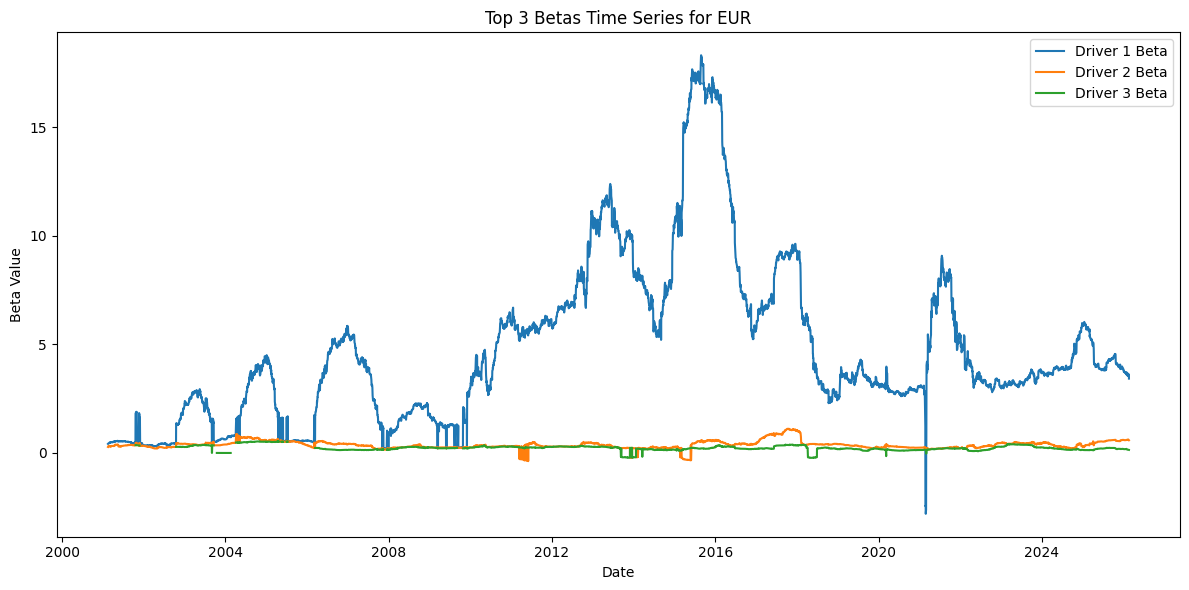

In [22]:
import matplotlib.pyplot as plt

# Choose the key you want to plot, e.g., "eur"
key = "eur"
df = top_map[key]

# Plot the three beta time series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Driver 1 Beta"], label="Driver 1 Beta")
plt.plot(df.index, df["Driver 2 Beta"], label="Driver 2 Beta")
plt.plot(df.index, df["Driver 3 Beta"], label="Driver 3 Beta")
plt.xlabel("Date")
plt.ylabel("Beta Value")
plt.title(f"Top 3 Betas Time Series for {key.upper()}")
plt.legend()
plt.tight_layout()
plt.show()